# Generate the voxel scenes first
There are 2 benchmark types:
1. Multiple choice to choice the right view when front and top views are provided
2. Predict the right view with the 5 other views provided

In this notebook the voxel scenes are genereted. Use `src/benchmark/generate_datasets_for_benchmarks.ipynb` to generate the final benchmark datasets

In [3]:
import sys
from pathlib import Path
import json

# Add src to path for imports
sys.path.insert(0, str(Path.cwd().parent.parent.parent / "src"))

import numpy as np
from generation.scene import Color, is_space_empty, place_object, build_voxel_scene, ALLOWED_OBJECT_MASKS
from generation.visualization import show_isometric_view

## Generate a random scene

In [4]:
def select_allowed_objects_of_shape(shape):
    """
    Select from the ALLOWED_OBJECT_MASKS those that fit within the given shape.
    """
    return [obj for obj in ALLOWED_OBJECT_MASKS if all(d <= s for d, s in zip(np.array(obj).shape, shape))]

In [5]:
select_allowed_objects_of_shape((3, 3, 3))

[[[[1]]],
 [[[1]], [[1]]],
 [[[1], [1]]],
 [[[1, 1]]],
 [[[1]], [[1]], [[1]]],
 [[[1], [1], [1]]],
 [[[1, 1, 1]]],
 [[[1]], [[0]], [[1]]],
 [[[1], [0], [1]]],
 [[[1, 0, 1]]],
 [[[1, 1], [1, 1]]],
 [[[1, 1]], [[1, 1]]],
 [[[1], [1]], [[1], [1]]],
 [[[0, 1], [1, 0]]],
 [[[1, 0]], [[0, 1]]],
 [[[0, 1]], [[1, 0]]],
 [[[1, 0]], [[0, 1]]],
 [[[0], [1]], [[1], [0]]],
 [[[1], [0]], [[0], [1]]],
 [[[0, 1], [1, 1]]],
 [[[1, 0], [1, 1]]],
 [[[1, 1], [0, 1]]],
 [[[1, 1], [1, 0]]],
 [[[0, 1]], [[1, 1]]],
 [[[1, 0]], [[1, 1]]],
 [[[1, 1]], [[0, 1]]],
 [[[1, 1]], [[1, 0]]],
 [[[0], [1]], [[1], [1]]],
 [[[1], [0]], [[1], [1]]],
 [[[1], [1]], [[0], [1]]],
 [[[1], [1]], [[1], [0]]],
 [[[1, 1, 1], [1, 1, 1]]],
 [[[1, 1], [1, 1], [1, 1]]],
 [[[1, 1, 1]], [[1, 1, 1]]],
 [[[1], [1], [1]], [[1], [1], [1]]],
 [[[1, 1]], [[1, 1]], [[1, 1]]],
 [[[1], [1]], [[1], [1]], [[1], [1]]],
 [[[0, 1, 1], [1, 1, 1]]],
 [[[1, 0, 1], [1, 1, 1]]],
 [[[1, 1, 0], [1, 1, 1]]],
 [[[1, 1, 1], [0, 1, 1]]],
 [[[1, 1, 1], [1, 0, 1]]

In [6]:
def generate_random_scene(size, num_objects, only_cuboids, max_attempts=100):
    """
    Create a voxel based scene with ramdomly placed objects of random sizes and colors.

    Args:
        size (tuple, optional): _description_. Defaults to (4, 4, 4).
        num_objects (_type_, optional): _description_. Defaults to lambda:3.
        max_attempts (int, optional): _description_. Defaults to 100.
        max_attempts (int, optional): Maximum placement attempts per object before skipping it.

        Notes:
        `num_objects` supports two forms:
        - `int`: fixed number of objects.
        - `callable`: dynamic number of objects. The callable may accept `size`
          (e.g. `lambda size: np.random.randint(1, min(4, min(size)) + 1)`) or no
          arguments (e.g. `lambda: 3`).

    Returns:
        np.ndarray: 3D voxel grid (dtype int8) with placed objects using ARC color ids.
    """
    objects = []
    voxel_scene = build_voxel_scene(size, objects)  # Track occupied space
    available_colors = [c for c in Color if c != Color.BLACK]

    # num_objects can be an int or a callable (e.g., lambda)
    if callable(num_objects):
        try:
            n_objects = int(num_objects(size))
        except TypeError:
            n_objects = int(num_objects())
    else:
        n_objects = int(num_objects)

    n_objects = max(0, min(n_objects, len(available_colors)))

    for _ in range(n_objects):
        for _attempt in range(max_attempts):
            origin = tuple(np.random.randint(0, s) for s in size)
            object_size = tuple(
                np.random.randint(1, min(4, s - o) + 1) for s, o in zip(size, origin)
            )
            if only_cuboids:
                mask = np.ones(object_size, dtype=int)
            else:
                masks_selection = select_allowed_objects_of_shape(object_size)
                if masks_selection:
                    mask = np.array(masks_selection[np.random.randint(len(masks_selection))], dtype=int)
                else:
                    mask = np.ones(object_size, dtype=int)

            color = available_colors[np.random.randint(len(available_colors))]

            if is_space_empty(voxel_scene, origin, mask):
                objects.append({"origin": origin, "shape_mask": mask, "color": color})
                place_object(voxel_scene, origin, mask, color)
                break

    # Ensure at least 1 object is placed - fallback to simple 1x1x1 object
    if len(objects) == 0:
        # Place a guaranteed simple 1x1x1 object at a random position
        fallback_origin = tuple(np.random.randint(0, s) for s in size)
        fallback_mask = np.ones((1, 1, 1), dtype=int)
        fallback_color = available_colors[np.random.randint(len(available_colors))]
        objects.append({"origin": fallback_origin, "shape_mask": fallback_mask, "color": fallback_color})
        place_object(voxel_scene, fallback_origin, fallback_mask, fallback_color)

    return voxel_scene

[[[0 0 0 0 0]
  [0 0 0 0 0]
  [0 0 0 0 0]
  [0 0 0 0 0]
  [0 0 0 0 0]]

 [[0 0 0 0 0]
  [0 0 0 0 0]
  [0 0 0 0 0]
  [8 0 0 0 0]
  [0 9 0 0 0]]

 [[0 0 0 0 0]
  [0 0 0 0 0]
  [8 0 0 0 0]
  [0 0 0 0 0]
  [9 9 0 0 0]]

 [[0 0 8 0 0]
  [0 0 8 0 0]
  [0 0 8 0 8]
  [0 5 5 0 0]
  [0 5 5 0 0]]

 [[0 0 0 0 0]
  [0 0 0 0 0]
  [0 0 0 0 0]
  [0 0 0 0 0]
  [0 0 0 0 0]]]


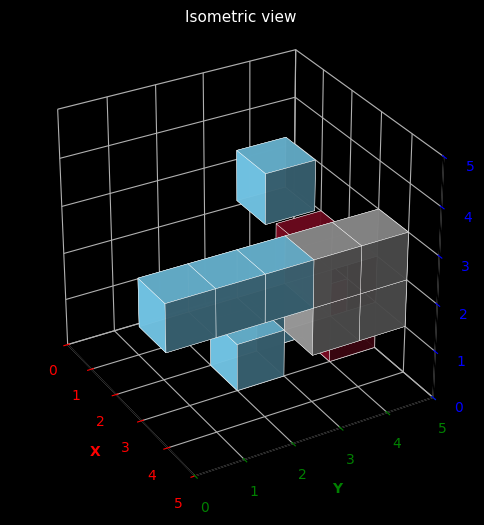

In [7]:
voxel_scene = generate_random_scene((5,5,5), num_objects=lambda: np.random.randint(3, 8), only_cuboids=False)
print(voxel_scene)
show_isometric_view(voxel_scene)

### Create dataset 
The dataset:
- Only the voxels are added using the `generate_random_scene` function
- By default, the size is cubical (size, size, size) and between 3 and 5
- Save it in JSON format
- Next step is to review the voxels using `src/mc_editor`
- Use seed to be able to recreate the dataset for reproducibility

Let number of objects depend on size, with a minimum of 1 and a maximum that grows with size, but is capped to avoid excessive complexity:

In [8]:
# Quick test of object count logic across different sizes
for task_size in range(3, 11):
    min_objects = task_size - 2 if task_size < 7 else 4
    max_objects = (min_objects * 2 + 2) if task_size < 7 else 10
    print(f"Size: {task_size}, Min objects: {min_objects}, Max objects: {max_objects}")

Size: 3, Min objects: 1, Max objects: 4
Size: 4, Min objects: 2, Max objects: 6
Size: 5, Min objects: 3, Max objects: 8
Size: 6, Min objects: 4, Max objects: 10
Size: 7, Min objects: 4, Max objects: 10
Size: 8, Min objects: 4, Max objects: 10
Size: 9, Min objects: 4, Max objects: 10
Size: 10, Min objects: 4, Max objects: 10


In [9]:
def generate_dataset(num_tasks: int, size: tuple[int, int, int], seed: int, random_size_range: tuple[int, int] | None = None):
    """
    Create a dataset with orthographic view tasks.

    Args:
        num_tasks: Number of tasks to generate
        size: Fixed cube size as (x, y, z) tuple, e.g., (3, 3, 3)
        seed: Random seed for reproducibility
        random_size_range: Optional (min_size, max_size) for random cubic sizes per task.
                          If provided, overrides the fixed size parameter.
    """

    if num_tasks < 1 or num_tasks > 999:
        raise ValueError("num_tasks must be between 1 and 999.")
    if seed < 0 or seed > 99:
        raise ValueError("Seed must be between 0 and 99 for consistent task IDs.")
    
    np.random.seed(seed)

    dataset = {
        "tasks": [],
        "seed": seed,
    }

    for i in range(num_tasks):
        # Determine size for this task
        if random_size_range:
            task_size = np.random.randint(random_size_range[0], random_size_range[1])
            task_size_tuple = (task_size, task_size, task_size)
        else:
            task_size_tuple = size
            task_size = size[0]  # Assume cubic for object count calculation
        
        #min_max_objects =[[1, 4], [2, 6], [3, 8], [4, 10], [1, 12], [1, 15], [1, 20], [1, 25]]
        min_objects = task_size - 2 if task_size < 7 else 4
        max_objects = (min_objects * 2 + 2) if task_size < 7 else 10
        n_objects = np.random.randint(min_objects, max_objects)

        voxel_scene = generate_random_scene(size=task_size_tuple, num_objects=n_objects, only_cuboids=False)

        task = {
            "id": f"{seed:02d}_{i+1:03d}",
            "voxels": voxel_scene.tolist(),
        }
        dataset["tasks"].append(task)

    return dataset

Save the dataset with 200 tasks. The use can select in the notebook less tasks using `dataset['tasks'][:TASKS_SIZE]`.

In [ ]:
def create_and_save_datasets(size: tuple[int, int, int], size_name: str, seed: int, random_size_range: tuple[int, int] | None = None):
    ds = generate_dataset(num_tasks=200, size=size, seed=seed, random_size_range=random_size_range)
    output_path = Path.cwd().parent.parent.parent / "datasets" / "raw" / f"orthographic_dataset_{size_name}_tasks.json"
    output_path.parent.mkdir(parents=True, exist_ok=True)

    with open(output_path, "w") as f:
        json.dump(ds, f, indent=2)
    print(f"Dataset saved to: {output_path}")

## List of defined datasets for the benchmarks

In [15]:
create_and_save_datasets(
    size=(3, 3, 3),
    size_name="fixed_3",
    seed=42
)

Dataset saved to: /Users/joost/vscode/ai-measuring-toward-agi-competition/datasets/raw/orthographic_dataset_fixed_3_tasks_1.json


In [12]:
create_and_save_datasets(
    size=(4, 4, 4),
    size_name="fixed_4",
    seed=42
)

Dataset saved to: /Users/joost/vscode/ai-measuring-toward-agi-competition/src/datasets/raw/orthographic_dataset_fixed_4_tasks_1.json


In [13]:
create_and_save_datasets(
    size=(5, 5, 5),
    size_name="fixed_5",
    seed=42
)

Dataset saved to: /Users/joost/vscode/ai-measuring-toward-agi-competition/src/datasets/raw/orthographic_dataset_fixed_5_tasks_1.json


## Review datasets
Use the webbased viewer to review the dataset, see `src/task_viewer`.